# 08 · Single depth vs the whole curve: phase maps

*A depth-resolved map is a whole stack of single-depth maps. Here's what that buys you.*

> ⏱ **Runtime:** ~10 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** Al–Cu depth-resolved map

### 🎯 What you'll learn
1. the difference between a **single-depth** map and a **depth-resolved** one,
2. how to segment the two Al–Cu phases from **one depth**, and why the depth you pick matters,
3. how using the **whole depth curve** gives a more robust phase map,
4. how to check two segmentations agree (**ARI**).

### 🧭 What you need to know first
- Clustering from notebook **02** and PCA from **01**.
- That a depth-resolved map keeps the full hardness-vs-depth curve at every point (notebook 00).

> 🧭 **Single-depth vs depth-resolved.** A **single-depth** map gives one hardness/modulus per point
> (notebook 02 used one). A **depth-resolved** map keeps the *whole* hardness-vs-depth curve at every
> point. So it is really a **stack of single-depth maps**, one per depth, plus the option to use the
> entire curve at once. This notebook shows why that flexibility helps.

### Step 0: set-up

Begin with the cell below and run it with **Shift + Enter**.

> 🟢 **On Google Colab** the same cell clones the repo and grabs a few extra packages (about a minute, once per session). Locally, after `pip install -r requirements.txt`, it is instant.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py`. That confirms the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.metrics import adjusted_rand_score
rng = np.random.default_rng(0)

## 1 · A depth-resolved Al–Cu map

The Al–Cu eutectic has two phases: a **soft Al-rich matrix** and a **hard Al₂Cu intermetallic**. Our
map keeps the full hardness-vs-depth curve at every indent.

> 🧠 **phase**: a region of distinct composition/structure (here the soft matrix vs the hard intermetallic) that we want to map.

> ✅ **Expect:** the map size (~20,000 indents), a few hardness-vs-depth curves in two clear bands (soft and hard), and a **bimodal** hardness histogram = two phases.

indents: 19718  depth points: 56


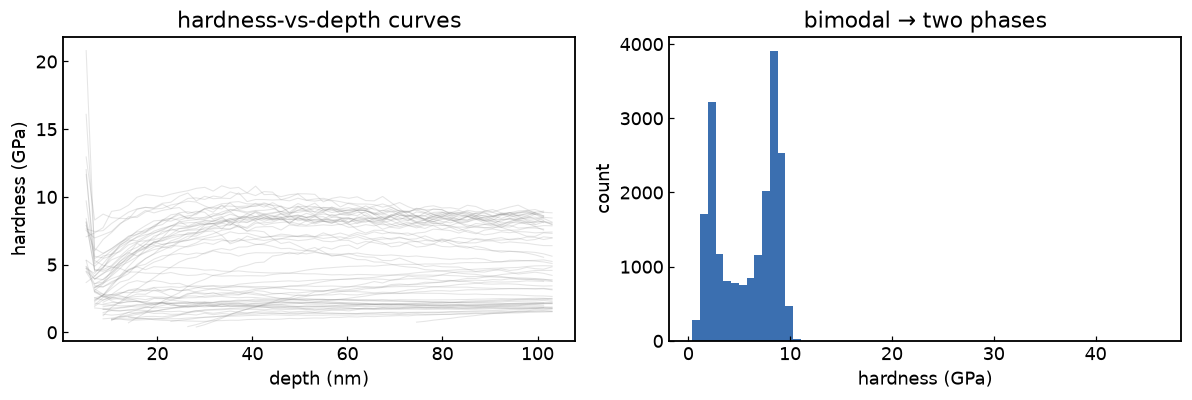

In [3]:
d = mm.load_hsnm_map("alcu_eutectic")
depth = d["depth_nm"]; H = d["H"]; E = d["E"]; X, Y = d["X"], d["Y"]
print("indents:", H.shape[0], " depth points:", H.shape[1])

# One representative hardness per indent = the average of its curve over 40–90 nm.
# (written to skip the rare indent with no finite point in that band, without warnings)
band = (depth >= 40) & (depth <= 90)
n_ok = np.isfinite(H[:, band]).sum(axis=1)                       # finite points per indent in the band
Hmid = np.divide(np.nansum(H[:, band], axis=1), n_ok,           # finite-only mean, NaN if none
                 out=np.full(H.shape[0], np.nan), where=n_ok > 0)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for i in rng.choice(H.shape[0], 60, replace=False):
    ax[0].plot(depth, H[i], color="grey", alpha=0.2, lw=0.7)
ax[0].set_xlabel("depth (nm)"); ax[0].set_ylabel("hardness (GPa)"); ax[0].set_title("hardness-vs-depth curves")
ax[1].hist(Hmid[np.isfinite(Hmid)], bins=60, color="#3b6fb0")
ax[1].set_xlabel("hardness (GPa)"); ax[1].set_ylabel("count"); ax[1].set_title("bimodal → two phases")
fig.tight_layout()

*🖼 **Figure.** Left: the curves fall into two bands. Right: two humps in the histogram: the soft matrix (~2–3 GPa) and the hard Al₂Cu (~7–8 GPa).*

## 2 · Phase map from a **single depth**

Pick one depth, take `H` and `E` there, and cluster into two groups (as notebook 02 did on a
single-depth map). This works, but the result depends on the depth you choose.

> ✅ **Expect:** a phase map from a mid depth; the two phases appear as coherent regions. The printed cluster hardnesses are clearly different (soft vs hard).

at 50 nm — matrix H ≈ 2.8, intermetallic H ≈ 8.2 GPa


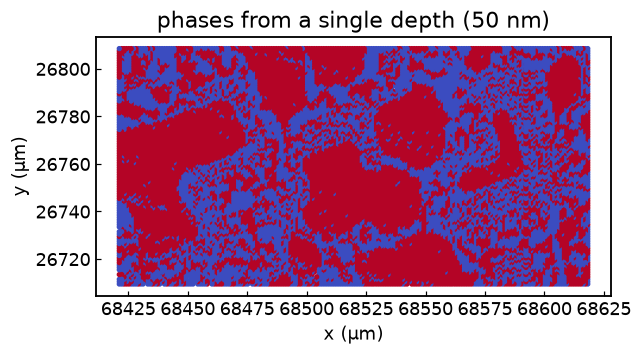

In [4]:
def phase_map_at(depth_nm):
    j = int(np.argmin(np.abs(depth - depth_nm)))
    F = np.column_stack([H[:, j], E[:, j]])
    F = SimpleImputer(strategy="median").fit_transform(F)
    lab = KMeans(2, n_init=10, random_state=0).fit_predict(StandardScaler().fit_transform(F))
    # name the clusters: label 1 = the harder phase (higher mean hardness at this depth)
    hard = lab == int(np.argmax([np.nanmean(H[lab == c, j]) for c in (0, 1)]))
    return hard.astype(int)

single = phase_map_at(50)                        # single-depth phases at 50 nm
j = int(np.argmin(np.abs(depth - 50)))
print(f"at {depth[j]:.0f} nm — matrix H ≈ {np.nanmean(H[single==0, j]):.1f}, "
      f"intermetallic H ≈ {np.nanmean(H[single==1, j]):.1f} GPa")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.scatter(X, Y, c=single, s=6, cmap="coolwarm"); ax.set_aspect("equal")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)"); ax.set_title(f"phases from a single depth ({depth[j]:.0f} nm)")
fig.tight_layout()

*🖼 **Figure.** A perfectly good phase map (from one depth). But which depth? Too shallow and surface artefacts blur it; the depth-resolved data lets us do better.*

## 3 · Phase map from the **whole curve**

Instead of one depth, use the **entire** hardness curve of each indent: compress it with PCA (as in
notebook 01), then cluster. No arbitrary depth to choose, and it uses all the information.

> ✅ **Expect:** a phase map from the whole curve (cleaner/coherent) and the PCA keeps most of the variance in a couple of components.

variance kept by 5 components: 0.98
intermetallic fraction (whole-curve): 0.57


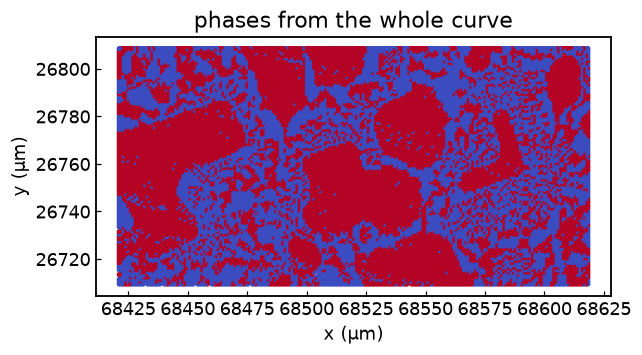

In [5]:
C = SimpleImputer(strategy="median").fit_transform(H)   # (n_indents, n_depth) hardness curves
Cs = StandardScaler().fit_transform(C)
pca = PCA(n_components=5).fit(Cs)                        # compress each curve to 5 numbers
scores = pca.transform(Cs)
print("variance kept by 5 components:", round(float(pca.explained_variance_ratio_.sum()), 2))
lab = KMeans(2, n_init=10, random_state=0).fit_predict(scores)
whole = (lab == int(np.argmax([np.nanmean(Hmid[lab == c]) for c in (0, 1)]))).astype(int)  # 1 = harder
print("intermetallic fraction (whole-curve):", round(float(whole.mean()), 2))

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.scatter(X, Y, c=whole, s=6, cmap="coolwarm"); ax.set_aspect("equal")
ax.set_xlabel("x (µm)"); ax.set_ylabel("y (µm)"); ax.set_title("phases from the whole curve")
fig.tight_layout()

*🖼 **Figure.** Using the full curve needs no choice of depth and pools all the evidence: a robust phase map straight from the raw curves.*

## 4 · Do they agree?

Compare the single-depth and whole-curve phase maps with the **Adjusted Rand Index** (1 = identical).
High agreement means the phases are real; where they differ is usually the noisy near-surface.

> ✅ **Expect:** a printed **ARI around 0.8+** (strong agreement) and the two maps side by side.

ARI(single-depth, whole-curve) = 0.86
single-depth agreement with whole-curve:  at 15 nm = 0.83,  at 80 nm = 0.93


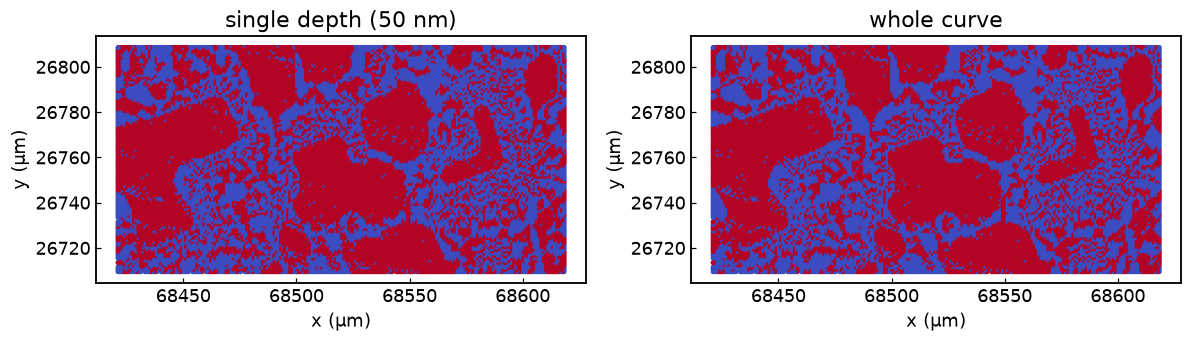

In [6]:
ari = adjusted_rand_score(single, whole)
print(f"ARI(single-depth, whole-curve) = {ari:.2f}")

# how much does the single-depth answer wobble with the chosen depth?
agree_shallow = (phase_map_at(15) == whole).mean()
agree_deep = (phase_map_at(80) == whole).mean()
print(f"single-depth agreement with whole-curve:  at 15 nm = {agree_shallow:.2f},  at 80 nm = {agree_deep:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, lab_, t in [(ax[0], single, "single depth (50 nm)"), (ax[1], whole, "whole curve")]:
    a.scatter(X, Y, c=lab_, s=6, cmap="coolwarm"); a.set_aspect("equal"); a.set_title(t)
    a.set_xlabel("x (µm)"); a.set_ylabel("y (µm)")
fig.tight_layout()

*🖼 **Figure.** The two maps largely agree (high ARI). The single-depth answer shifts with the depth you pick (shallow agrees less); the whole-curve map needs no such choice.*

### ✅ Self-check
Before moving on, confirm the numbers above make sense. The cell below raises an `AssertionError` if a later change sends a result off the rails.

In [7]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert abs(np.nanmean(H[single==1, j]) - np.nanmean(H[single==0, j])) > 2, "the two phases should differ clearly in hardness"
assert 0.1 < whole.mean() < 0.9, "both phases should be present in the whole-curve map"
assert ari > 0.5, "single-depth and whole-curve phase maps should broadly agree"
print("self-check passed ✓ — two phases mapped both ways")

self-check passed ✓ — two phases mapped both ways


## ✅ Recap
- A **depth-resolved** map is a stack of **single-depth** maps. You can cluster at any one depth, or use the whole curve.
- A **single-depth** phase map works but depends on the depth you pick (shallow is noisier).
- Using the **whole curve** (PCA → cluster) needs no chosen depth and gives a robust phase map; **ARI** confirms they agree.

## 🔧 Try it yourself
Play with it. Re-run the cell after each of these:
1. Change the single-depth in Part 2 from 50 nm to 15 nm and re-run. Does the phase map get noisier?
2. Cluster into **3** groups on the whole curve. Do you resolve an interface/edge population?
3. Repeat Part 3 on the **modulus** curves (`E`) instead of hardness. Do you get the same phases?

## 🩹 Common errors & fixes
- **`ValueError: Input contains NaN`** → make sure the `SimpleImputer` cell ran before clustering.
- **Phase colours swap between runs** → cluster ids are arbitrary; we name the harder phase by mean hardness.
- **`FileNotFoundError`** → run the set-up cell first so `mm.load_hsnm_map` finds `data/hsnm_maps/`.

---
**Next:** **`07_substrate_layer_deconvolution.ipynb`** applies the same depth-resolved idea to coatings, or revisit **`02`** for clustering on single-depth features.